#  Statistique bivariée & tests statistiques  
Introduction aux tests statistiques  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

try:
    import seaborn as sns
    sns.set(style="whitegrid")
    
except:
    sns = None
# chargement du jeu de données 
df = pd.read_csv("ecommerce_dataset.csv")
df.head()

,client_id,sexe,âge,revenu_mensuel,segment_age,revenu_cat,produit,canal_achat,montant_panier,panier_frequent,note_satisfaction,retour_produit,date_achat
0,1,Homme,50,3893.70,Mature,Moyen,Sport,Mobile,83.27,Non,2,Non,2023-05-28
1,2,Femme,39,2885.15,Adulte,Moyen,Électronique,Mobile,47.18,Oui,3,Non,2023-01-13
2,3,Homme,44,2369.53,Mature,Moyen,Sport,Mobile,72.28,Oui,4,Non,2023-03-13
3,4,Homme,38,3197.92,Adulte,Moyen,Électronique,Mobile,54.59,Non,3,Non,2023-05-07
4,5,Homme,20,3774.66,Jeune,Moyen,Sport,Mobile,75.30,Non,4,Non,2023-07-04


Question :  
> Les hommes et les femmes dépensent-ils la même chose en moyenne ?

In [2]:
# regroupe les lignes par sexe puis calcule des statistiques descriptives
# sur le montant du panier pour chaque groupe
# ".T" pour inverser lignes et colonnes, pour lire les indicateurs plus facilement

var_quali = "sexe"
var_quanti = "montant_panier"

df[[var_quali, var_quanti]].groupby(var_quali).describe().T

sexe                        Femme        Homme
montant_panier count  7479.000000  7521.000000
               mean     87.985717    98.698502
               std      62.056393    69.787790
               min      10.320000    11.430000
               25%      45.050000    51.340000
               50%      69.830000    77.940000
               75%     111.410000   124.250000
               max     664.400000   929.970000

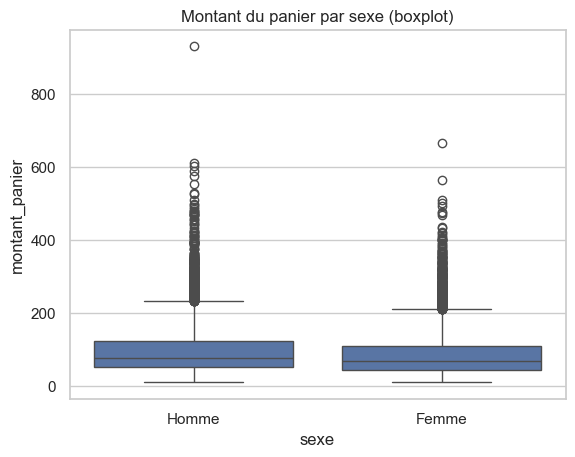

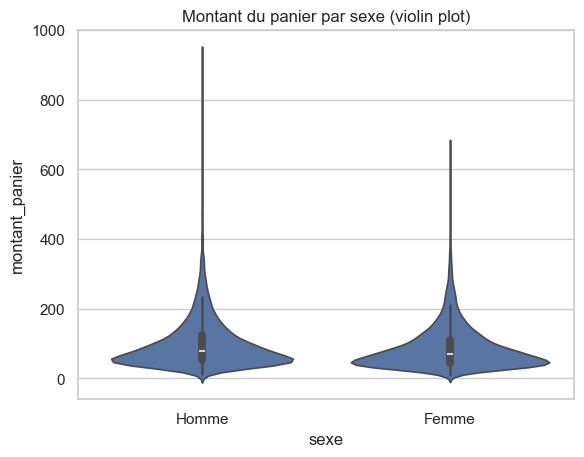

In [3]:
plt.figure()
if sns is not None:
    # boxplot quui montre médiane, quartiles et valeurs extrêmes par groupe
    sns.boxplot(x=var_quali, y=var_quanti, data=df)
else:
    # avec matplotlib seul, sans seaborn
    groups = [g[var_quanti].values for _, g in df.groupby(var_quali)]
    labels = df[var_quali].unique()
    plt.boxplot(groups, labels=labels)
plt.title("Montant du panier par sexe (boxplot)")
plt.show()

# forme de la distribution en plus des quartiles
if sns is not None:
    plt.figure()
    sns.violinplot(x=var_quali, y=var_quanti, data=df)
    plt.title("Montant du panier par sexe (violin plot)")
    plt.show()

###  Vérification des hypothèses (normalité, variances)

In [4]:
from scipy.stats import shapiro, levene, mannwhitneyu

#groupes pour Levene, à partir de var_quali
groupes = [g[var_quanti].dropna().values for _, g in df.groupby(var_quali)]
labels = df[var_quali].unique()
# test de Shapiro groupe par groupe vérifie si les données suivent une loi normale
# H₀ = les données suivent une loi normale
for label, g in df.groupby(var_quali):
    vals = g[var_quanti].dropna()
    # Shapiro est calculé sur un sous-échantillon aléatoire de 500 valeurs pas sur tout le grp
    stat, p = shapiro(vals.sample(min(len(vals), 500), random_state=42))
    print(f"Shapiro pour {label} : stat={stat:.3f}, p={p:.3f}, n={len(vals)}")

g1, g2 = groupes
# test de Levene vérifie si les deux groupes ont une variance comparable
# H₀ = les variances sont égales
stat_lev, p_lev = levene(g1, g2)
print(f"\nTest de Levene (égalité des variances) : stat={stat_lev:.3f}, p={p_lev:.3f}")

Shapiro pour Femme : stat=0.797, p=0.000, n=7479
Shapiro pour Homme : stat=0.721, p=0.000, n=7521

Test de Levene (égalité des variances) : stat=31.399, p=0.000


In [5]:
# STUDENT
t_stat, t_p = stats.ttest_ind(g1, g2, equal_var=True)
print("t-test indépendant ")
print(f"t = {t_stat:.3f}, p = {t_p:.3e}\n")

# WELCH compare les MOYENNES
t_stat, t_p = stats.ttest_ind(g1, g2, equal_var=False) 
print("t-test indépendant (Welch)")
print(f"t = {t_stat:.3f}, p = {t_p:.3e}\n")

# Mann-Whitney compare les distributions
mw_stat, mw_p = mannwhitneyu(g1, g2, alternative="two-sided")
print("Test de Mann–Whitney")
print(f"U = {mw_stat:.3f}, p = {mw_p:.3e}")

t-test indépendant 
t = -9.933, p = 3.536e-23

t-test indépendant (Welch)
t = -9.936, p = 3.431e-23

Test de Mann–Whitney
U = 25182676.500, p = 1.326e-28


## Conclusion

Les variances diffèrent entre hommes et femmes (Levene, p < 0,001) et les distributions sont très asymétriques (Shapiro). 

Comme l'échantillon est grand, on compare les moyennes avec le test de Welch, qui tolère des variances inégales. Il indique une différence significative (p = 3,4e-23) : les hommes dépensent en moyenne 98,70 € contre 87,99 € pour les femmes, soit environ 10,71 € de plus (+12 %).

Le test de Mann-Whitney, qui compare les distributions et non les moyennes, confirme ce résultat (p = 1,3e-28), tout comme les médianes (77,94 € vs 69,83 €). La différence n'est donc pas due à quelques très gros paniers.
Le boxplot montre des distributions qui se chevauchent largement. La différence est réelle, mais elle ne sépare pas nettement les deux groupes.

En résumé, il existe une différence significative entre les dépenses moyennes des hommes et des femmes. Les hommes dépensent un peu plus (environ 12 % de la moyenne des femmes). Sur un échantillon de cette taille, un test aussi puissant détecte des différences même faibles. L'écart est modeste, mais réel.

**langage métier**

Il existe une différence entre les dépenses des hommes et des femmes. Les hommes dépensent en moyenne 98.70 €, les femmes 87.99 €, soit un écart d'environ 10.71 €. La médiane confirme cette tendance (77.94 € contre 69.83 €), donc ce n'est pas dû à de gros achats isolés.
L'écart représente environ 12 % de la dépense moyenne des femmes. 

Implication métier : Le montant moyen diffère selon le sexe, mais l'effet reste limité. Il peut justifier une segmentation légère, mais ne doit pas être surinterprété comme un facteur déterminant du comportement d'achat. 
*l'écart s'explique enfaite en grande partie par la catégorie de produit (voir régression)*

Question :  
> Le montant du panier dépend-il de la tranche d'âge du client ?

In [6]:
var_quali_multi = "segment_age"
var_quanti_multi = "montant_panier"

df[[var_quali_multi, var_quanti_multi]].groupby(var_quali_multi).describe().T


segment_age                Adulte        Jeune       Mature      Senior
montant_panier count  7608.000000  1676.000000  5550.000000  166.000000
               mean     93.912940    92.168079    92.670004  102.859880
               std      67.283033    63.279226    65.595479   70.089715
               min      10.320000    11.320000    10.370000   23.210000
               25%      48.562500    48.710000    47.762500   51.655000
               50%      73.850000    73.620000    72.720000   86.460000
               75%     117.215000   115.650000   117.272500  129.495000
               max     929.970000   470.160000   603.400000  498.110000

### Vérification des hypothèses (normalité, variances)

In [7]:
# on récupère les valeurs de montant_panier pour chaque segment d'âge
groups_multi = [g[var_quanti_multi].dropna().values for _, g in df.groupby(var_quali_multi)]

# test de Shapiro pour chaque segmen pour vérifier la normalité toujours sur sous echantillon de 500
for label, g in df.groupby(var_quali_multi):
    vals = g[var_quanti_multi].dropna()
    stat, p = shapiro(vals.sample(min(len(vals), 500), random_state=42))
    print(f"Shapiro pour {label} : stat={stat:.3f}, p={p:.3f}, n={len(vals)}")

# test de Levene sur tous les groupes en même temps
# H₀ : les variances sont égales entre les segments d'âge
stat_lev_anova, p_lev_anova = stats.levene(*groups_multi)
print(f"\nTest de Levene (ANOVA) : stat={stat_lev_anova:.3f}, p={p_lev_anova:.3f}")


Shapiro pour Adulte : stat=0.714, p=0.000, n=7608
Shapiro pour Jeune : stat=0.823, p=0.000, n=1676
Shapiro pour Mature : stat=0.821, p=0.000, n=5550
Shapiro pour Senior : stat=0.847, p=0.000, n=166

Test de Levene (ANOVA) : stat=1.364, p=0.252


### ANOVA & Kruskal–Wallis

In [8]:
# ANOVA à un facteur
# H0 : toutes les moyennes de segment_age sont égales
f_stat, f_p = stats.f_oneway(*groups_multi)
print("ANOVA à un facteur")
print(f"F = {f_stat:.3f}, p = {f_p:.3e}\n")

# test de Kruskal-Wallis : équivalent non paramétrique de l'ANOVA
# suppose pas la normalité, backup si Shapiro rejete
kw_stat, kw_p = stats.kruskal(*groups_multi)
print("Test de Kruskal–Wallis")
print(f"H = {kw_stat:.3f}, p = {kw_p:.3e}")

ANOVA à un facteur
F = 1.696, p = 1.656e-01

Test de Kruskal–Wallis
H = 5.098, p = 1.648e-01


## Conclusion

Le test de Shapiro rejette la normalité pour les quatre segments (p < 0.001 dans tous les cas). Le test de Levene ne rejette pas l'égalité des variances (p = 0.252). Les dispersions sont donc comparables entre segments.

Malgré la non-normalité, l'échantillon est assez grand pour que l'ANOVA reste fiable pour comparer les moyennes. Elle ne met pas en évidence de différence (F = 1.696, p = 0.166). Kruskal-Wallis, qui compare les distributions, donne la même conclusion (H = 5.098, p = 0.165). Les deux tests s'accordent.

*(Si ANOVA significative → au moins un segment d'âge diffère des autres. Pour voir quels groupes diffèrent, tests post-hoc (Tukey / Dunn)*

Les moyennes par segment sont proches : 93.91 € pour les Adultes, 92.17 € pour les Jeunes, 92.67 € pour les Matures, 102.86 € pour les Seniors. Le segment Senior se détache un peu, mais avec seulement 166 observations contre plusieurs milliers pour les autres segments. Un écart sur un groupe aussi petit reste fragile.

En résumé, aucune différence significative n'apparaît entre les segments d'âge sur le montant du panier.

Implication métier : l'âge ne permet pas d'expliquer les écarts de panier moyen. Le segment Senior mérite d'être revérifié sur un échantillon plus large avant toute conclusion.


Question :  
> Y a-t-il un lien entre le sexe des clients et le fait qu'ils retournent le produit ?

In [9]:
# Tableau croisé des effectifs
# nombre de clients pour chaque combinaison sexe / retour_produit
var_q1 = "sexe"
var_q2 = "retour_produit"

table = pd.crosstab(df[var_q1], df[var_q2])
table

retour_produit,Non,Oui
sexe,,
Femme,6722,757
Homme,6718,803


In [10]:
# proportions par ligne (chaque ligne = 100 %)
# On rapporte chaque effectif à la taille du groupe (sexe) pour comparer les taux de retour indépendamment des effectifs de départ
table_prop = table.div(table.sum(axis=1), axis=0) * 100
table_prop

retour_produit,Non,Oui
sexe,,
Femme,89.878326,10.121674
Homme,89.323228,10.676772


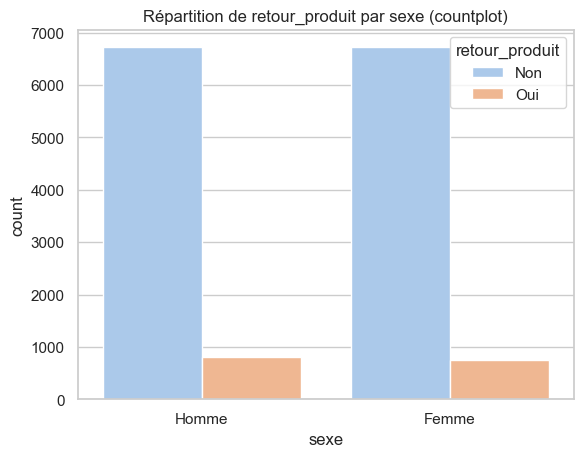

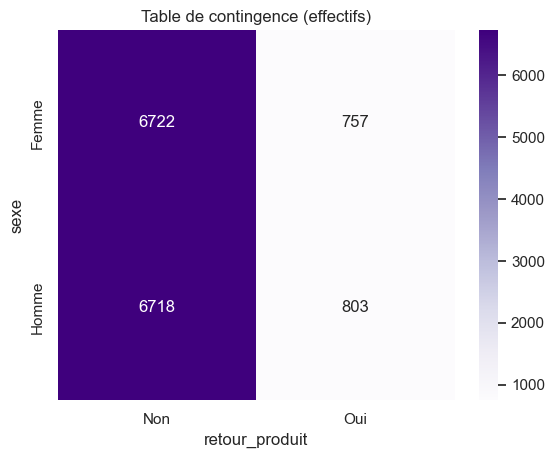

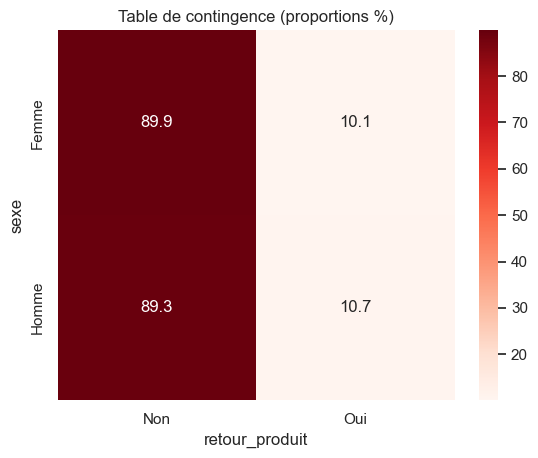

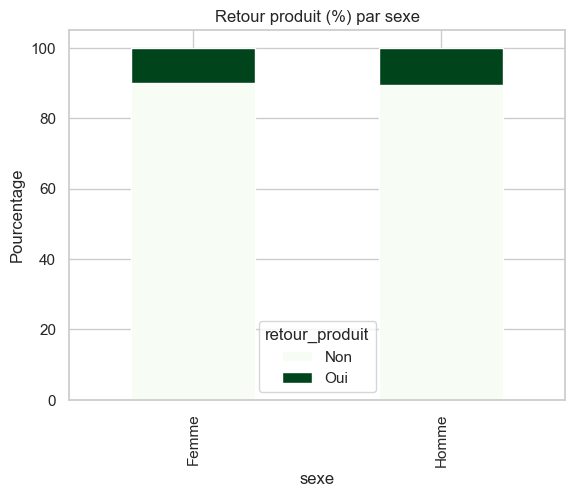

In [11]:

if sns is not None:
    plt.figure()
    sns.countplot(x=var_q1, hue=var_q2, data=df, palette ="pastel")
    plt.title("Répartition de retour_produit par sexe (countplot)")
    plt.show()

    plt.figure()
    sns.heatmap(table, annot=True, fmt="d", cmap="Purples")
    plt.title("Table de contingence (effectifs)")
    plt.ylabel(var_q1)
    plt.xlabel(var_q2)
    plt.show()

    plt.figure()
    sns.heatmap(table_prop, annot=True, fmt=".1f", cmap="Reds")
    plt.title("Table de contingence (proportions %)")
    plt.ylabel(var_q1)
    plt.xlabel(var_q2)
    plt.show()

table_prop.plot(kind="bar", stacked=True,colormap="Greens")
plt.ylabel("Pourcentage")
plt.title("Retour produit (%) par sexe")
plt.legend(title=var_q2)
plt.show()


In [15]:
# test du Khi-deux d'indépendance sur le tableau de contingence
chi2, p_chi2, dof, expected = stats.chi2_contingency(table)
print(f"Test du Chi² : chi2 = {chi2:.3f}, p = {p_chi2:.3e}, ddl = {dof}")

Test du Chi² : chi2 = 1.181, p = 2.771e-01, ddl = 1


In [13]:
from scipy.stats import fisher_exact

if table.shape == (2, 2):
    oddsratio, p_fisher = fisher_exact(table)
    print(f"Test exact de Fisher : odds ratio = {oddsratio:.3f}, p = {p_fisher:.3e}")
else:
    print("La table n'est pas 2x2 : Fisher exact non applicable directement.")

Test exact de Fisher : odds ratio = 1.061, p = 2.728e-01


In [14]:
# V de Cramér : force du lien entre les deux variables avec correction du biais (Bergsma)
n = table.to_numpy().sum()
phi2 = chi2 / n
r, k = table.shape
phi2_corr = max(0, phi2 - (k-1)*(r-1)/(n-1))
r_corr = r - (r-1)**2/(n-1)
k_corr = k - (k-1)**2/(n-1)
cramers_v = np.sqrt(phi2_corr / min((k_corr-1), (r_corr-1)))
print(f"V de Cramér : {cramers_v:.3f}")


V de Cramér : 0.003


Le test du Khi-deux ne rejette pas l'indépendance (mais ne la prouve pas non plus) entre sexe et retour_produit (chi2 = 1.181, p = 0.277). Le test exact de Fisher donne la même conclusion (odds ratio = 1.061, p = 0.273). Les deux tests s'accordent.
Le V de Cramér est de 0.003, quasiment nul. Même si le test avait été significatif, l'association aurait été négligeable en pratique.
Les taux de retour par sexe sont proches : 10.12 % pour les femmes, 10.68 % pour les hommes. L'écart est inférieur à un point.
En résumé, le sexe ne semble pas jouer de rôle dans le retour du produit.


**Langage métier** : Aucun lien détectable entre sexe et retour produit. Les femmes retournent le produit dans 10.1 % des cas, les hommes dans 10.7 %. Le sexe n'est pas un critère utile pour anticiper les retours.